<a href="https://colab.research.google.com/github/deezjason/HillcrestWesbite/blob/main/Suya_analysis_Jason.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib as mt
import seaborn as sns
import numpy as np
import random

In [ ]:
name="Garba's Hut"
unitprice=2700
quantity=1
print(name,"sold",quantity, "suya at", unitprice, "per unit")

price=int(input("What is your price?"))
quantity=int(input("How many are you selling?"))

print("your total will be",price*quantity)

conv="1500"
conv=int(conv)
print(conv+250)

Garba's Hut sold 1 suya at 2700 per unit
What is your price?3
How many are you selling?1
your total will be 3
1750


In [ ]:
sen="  beef suya  "
sen=sen.replace("  ","").upper()
print(sen)

menu=["suya","masa","bread","rice","meat"]
chicken=["chicken"]
menu=menu+chicken
print(menu)

menudict={'suya': 100, 'masa':50, 'bread':250}
print(menudict['suya'])

cashflow=["Cash", "POS", "Cash", "Transfer"]
setcash=set(cashflow)

fullmenudict={'suya': 100, 'masa':50, 'bread':250, 'rice':300, 'meat':500, 'chicken':450}
customerbuy=["suya", "masa", "bread"]
totalprice=fullmenudict['suya']+fullmenudict['masa']+fullmenudict['bread']
print(totalprice)



BEEF SUYA
['suya', 'masa', 'bread', 'rice', 'meat', 'chicken']
100
400


In [ ]:
for number in range(1,11):
  print(number)
total=10000
if (total>5000):
    print("Big order")

else:
    print("Small order")

def add_vat(price):
  price=price*(7.5/100)+price

SyntaxError: invalid syntax (530611323.py, line 15)

In [ ]:

try:
  int(input("Put in a number"))
except ValueError:
    print("That is not a number")
random_food=random.choice(menu)
print(random_food)

with open("output.txt","w") as file:
  file.write(menu[0])
  file.write(menu[1])
  file.write(menu[2])
with open("output.txt","r") as file:
  print(file.read())







Put in a numberf
That is not a number
suya
suyamasabread


In [ ]:
arr1=np.array([2700,2050,1500,2000,1700,1800])
print(arr1.mean())
print(arr1.max())
print(arr1.min())
arr1=(arr1*0.1)+arr1
arr1=arr1+200
print(arr1)



1958.3333333333333
2700
1500
[2970. 2255. 1650. 2200. 1870. 1980.]


In [ ]:
df=pd.read_csv('suya_orders.csv')
df.shape
df.head
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        5000 non-null   object 
 1   Date            5000 non-null   object 
 2   Branch          5000 non-null   object 
 3   Item            5000 non-null   object 
 4   Quantity        5000 non-null   int64  
 5   Unit_Price_NGN  5000 non-null   int64  
 6   Total_NGN       5000 non-null   int64  
 7   Payment_Method  4847 non-null   object 
 8   Customer_Age    4719 non-null   float64
 9   Rating          4604 non-null   float64
 10  Is_Delivery     5000 non-null   object 
dtypes: float64(2), int64(3), object(6)
memory usage: 429.8+ KB


In [ ]:
df.isna().sum()
df['Customer_Age']=df['Customer_Age'].fillna(df['Customer_Age'].median())
df['Payment_Method']=df['Payment_Method'].fillna("Unknown")
df.duplicated().sum()
df=df.drop_duplicates()
df['Date']=pd.to_datetime(df['Date'])




/tmp/ipykernel_747/2064623838.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Customer_Age']=df['Customer_Age'].fillna(df['Customer_Age'].median())
/tmp/ipykernel_747/2064623838.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Payment_Method']=df['Payment_Method'].fillna("Unknown")


,Is_Delivery
0,No
1,No
2,No
3,No
4,No
...,...
4995,Yes
4996,Yes
4997,No
4998,No


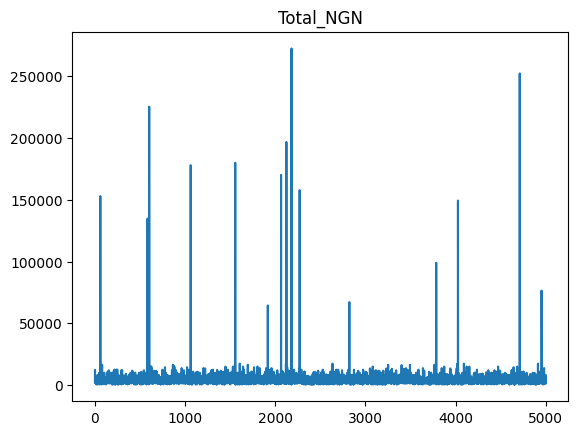

In [ ]:
df['Total_NGN'].sort_values(ascending=False).head(10)
df['Total_NGN'].plot(kind='line',title='Total_NGN')
df['Month']=df['Date'].dt.month
df['Is_Delivery'].replace({'yes':1,'no':0})

In [83]:
df['Total_NGN'].describe()
print(df['Total_NGN'].groupby(df['Branch']).mean())
print(df['Quantity'].corr(df['Total_NGN']))
print(df['Total_NGN'].mean())
print(df['Total_NGN'].median())
item_counts = df['Item'].value_counts()
print(item_counts)
payment_totals = df.groupby('Payment_Method')['Total_NGN'].sum()
display(payment_totals)



Branch
Abuja Wuse           4819.673123
Enugu Ogui           3963.080685
Ibadan Bodija        4207.449210
Jos Terminus         4362.094763
Kaduna Central       4097.458704
Kano Sabon Gari      4246.656761
Lagos Yaba           5702.312775
Port Harcourt GRA    3982.504970
Name: Total_NGN, dtype: float64
0.972416840409002
4541.141414141414
3300.0
Item
Beef Suya       1495
Chicken Suya    1142
Kilishi          708
Ram Suya         627
Gizzard          599
Soft Drink       379
Name: count, dtype: int64


,Total_NGN
Payment_Method,
Cash,8507300
POS,5758600
Transfer,7497850
Unknown,714900


In [94]:
print(df['Rating'].groupby(df['Branch']).mean())
print(df['Customer_Age'].corr(df['Total_NGN']))
print(df['Quantity'].corr(df['Rating']))
print(df['Is_Delivery'].value_counts(normalize=True)*100)




Branch
Abuja Wuse           4.065160
Enugu Ogui           4.055703
Ibadan Bodija        4.081340
Jos Terminus         4.059140
Kaduna Central       3.976323
Kano Sabon Gari      4.035200
Lagos Yaba           4.055156
Port Harcourt GRA    4.017316
Name: Rating, dtype: float64
-0.02358555296121142
-0.014589439057958472
Is_Delivery
No     71.818182
Yes    28.181818
Name: proportion, dtype: float64


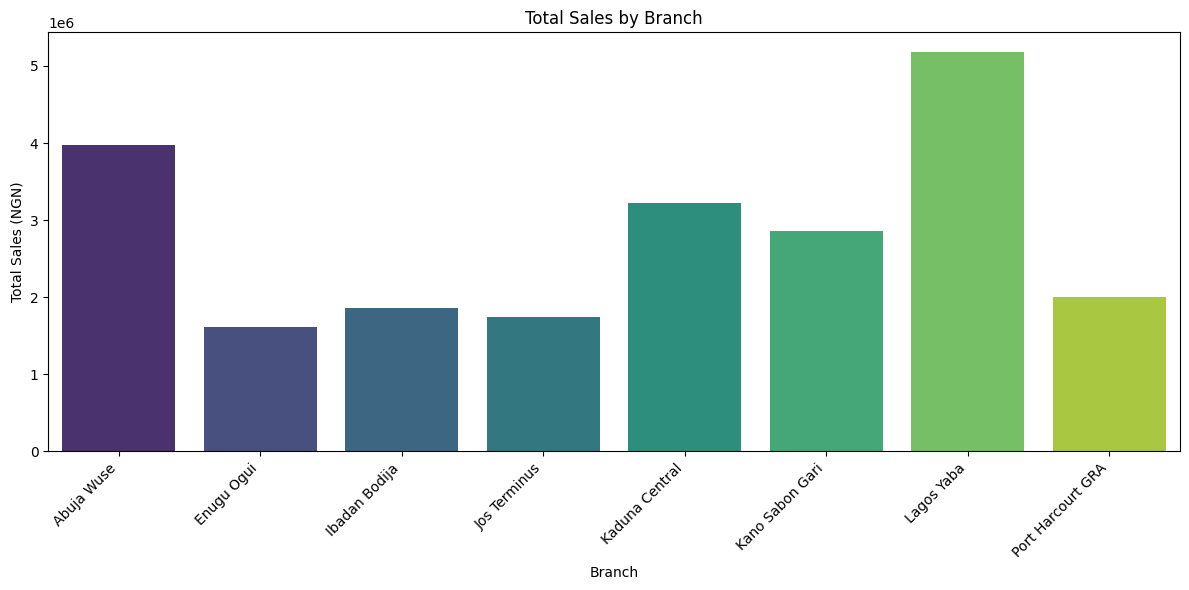

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Branch and calculate the sum of Total_NGN
branch_sales = df.groupby('Branch')['Total_NGN'].sum().reset_index()

# Draw the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=branch_sales, x='Branch', y='Total_NGN', palette='viridis', hue='Branch', legend=False)
plt.title('Total Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales (NGN)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Draw a boxplot of Total_NGN for each Item
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Item', y='Total_NGN', palette='Set2', hue='Item', legend=False)
plt.title('Distribution of Total Sales (NGN) by Item')
plt.xlabel('Item')
plt.ylabel('Total Sales (NGN)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Month and sum the Total_NGN
monthly_sales = df.groupby('Month')['Total_NGN'].sum().reset_index()

# Draw the line chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='Month', y='Total_NGN', marker='o', linewidth=2.5, color='orange')
plt.title('Total Sales Trend by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales (NGN)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(monthly_sales['Month'])
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of orders for each item
item_counts = df['Item'].value_counts().reset_index()
item_counts.columns = ['Item', 'Order_Count']

# Draw the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=item_counts, x='Item', y='Order_Count', palette='Set2', hue='Item', legend=False)
plt.title('Number of Orders for Each Item')
plt.xlabel('Item')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Draw a histogram of Customer_Age
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Customer_Age', bins=15, kde=True, color='skyblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Branch and calculate the average Rating
branch_ratings = df.groupby('Branch')['Rating'].mean().reset_index()

# Draw the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=branch_ratings, x='Branch', y='Rating', palette='coolwarm', hue='Branch', legend=False)
plt.title('Average Customer Rating by Branch')
plt.xlabel('Branch')
plt.ylabel('Average Rating')
plt.ylim(0, 5)  # Ratings are typically out of 5
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Draw a Seaborn countplot of Payment_Method
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Payment_Method', palette='Set3', order=df['Payment_Method'].value_counts().index)
plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Order Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Draw a scatter plot of Quantity against Total_NGN
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Quantity', y='Total_NGN', alpha=0.6, color='purple')
plt.title('Relationship between Quantity and Total Sales (NGN)')
plt.xlabel('Quantity Ordered')
plt.ylabel('Total Sales (NGN)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the specified columns and compute correlation
corr_matrix = df[['Quantity', 'Total_NGN', 'Customer_Age', 'Rating']].corr()

# Draw the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Month and count the number of orders
monthly_order_counts = df.groupby('Month')['Order_ID'].count().reset_index()
monthly_order_counts.columns = ['Month', 'Order_Count']

# Draw the line chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_order_counts, x='Month', y='Order_Count', marker='o', linewidth=2.5, color='teal')
plt.title('Total Number of Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(monthly_order_counts['Month'])
plt.tight_layout()
plt.show()

In [ ]:
print(df['Total_NGN'].mean())
print(df['Total_NGN'].median())
print(df['Total_NGN'].mode())
print(df['Customer_Age'].std())


In [ ]:
is_delivery_counts = df['Is_Delivery'].value_counts(normalize=True)
delivery_prob = is_delivery_counts.get('Yes', 0.0)
print(f"Probability of an order being a delivery: {delivery_prob:.4f} (or {delivery_prob * 100:.2f}%)")

In [ ]:
sample_df = df.sample(n=100, random_state=42)

sample_avg_sales = sample_df['Total_NGN'].mean()
overall_avg_sales = df['Total_NGN'].mean()

print(f"Average Total_NGN of the 100-order sample: {sample_avg_sales:.2f} NGN")
print(f"Average Total_NGN of all orders (population): {overall_avg_sales:.2f} NGN")
print(f"Difference: {abs(sample_avg_sales - overall_avg_sales):.2f} NGN")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Total_NGN', bins=30, kde=True, color='crimson')
plt.title('Distribution of Total Sales (NGN)')
plt.xlabel('Total NGN')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:

sample_200 = df.sample(n=200, random_state=42)

sample_mean = sample_200['Total_NGN'].mean()
sample_std = sample_200['Total_NGN'].std()
n = 200

margin_of_error = 1.96 * (sample_std / np.sqrt(n))

lower_limit = sample_mean - margin_of_error
upper_limit = sample_mean + margin_of_error

print(f"Sample Mean (n=200): {sample_mean:.2f} NGN")
print(f"Sample Standard Deviation: {sample_std:.2f} NGN")
print(f"Margin of Error: {margin_of_error:.2f} NGN")
print(f"95% Confidence Interval for the Average Total_NGN: [{lower_limit:.2f} NGN, {upper_limit:.2f} NGN]")